In [49]:
import random

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler


In [22]:
df = pd.read_csv("the_baseball_scholar_pitching_stats_1901_present_csv.csv")
df_filtered =df[df["season"] >= 2024]
df_filtered

,fangraphs_player_id,bbref_player_id,season,name_ascii,primary_position,era-,w,l,g,gs,...,hr,bb,so,ibb,whip,wp,hbp,bk,tbf,war
46,33677,skenepa01,2025,Paul Skenes,SP,45.853866,10,10,32,32,...,11,42,216,0,0.950854701,2,6,0,733,7.64
104,19427,biebesh01,2024,Shane Bieber,SP,0.000000,2,0,2,2,...,0,1,20,0,0.916666667,0,0,0,45,0.74
105,20778,sanchcr01,2025,Cristopher Sanchez,SP,58.342997,13,5,32,32,...,12,44,212,0,1.064356436,6,6,1,807,8.00
147,29960,smithaj01,2024,AJ Smith-Shawver,SP,0.000000,0,0,1,1,...,0,2,4,0,1.219512195,0,0,0,18,0.30
178,33677,skenepa01,2024,Paul Skenes,SP,46.485896,11,3,23,23,...,10,32,170,0,0.947368421,2,6,1,514,5.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46412,15941,nolaau01,2025,Austin Nola,RP,1504.193312,0,0,1,0,...,2,0,0,0,8,0,0,0,11,-0.19
46425,13420,kochma01,2024,Matt Koch,RP,1735.797106,0,0,2,0,...,1,1,0,0,40,0,0,0,5,-0.44
46428,19890,riverem01,2025,Emmanuel Rivera,RP,1783.265721,0,0,1,0,...,1,2,0,0,10,0,0,0,13,-0.19
46440,24458,duranca01,2025,Carlos Duran,RP,1923.229478,0,0,1,0,...,0,3,0,0,40,0,0,0,5,-0.15


In [30]:
features = ["era-", "w", "l", "g", "gs"]

X = df_filtered[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
distance_map = pairwise_distances(X_scaled, metric="euclidean")

g = nx.Graph()

for _, row in df_filtered.iterrows():
    player = row["name_ascii"]
    g.add_node(player)


for i in range(len(df_filtered)):
    for j in range(i + 1, len(df_filtered)):

        distance = distance_map[i][j]

        if distance <= 1.5:
            player_one = df_filtered.iloc[i]["name_ascii"]
            player_two = df_filtered.iloc[j]["name_ascii"]

            g.add_edge(
                player_one,
                player_two,
                weight=distance
            )


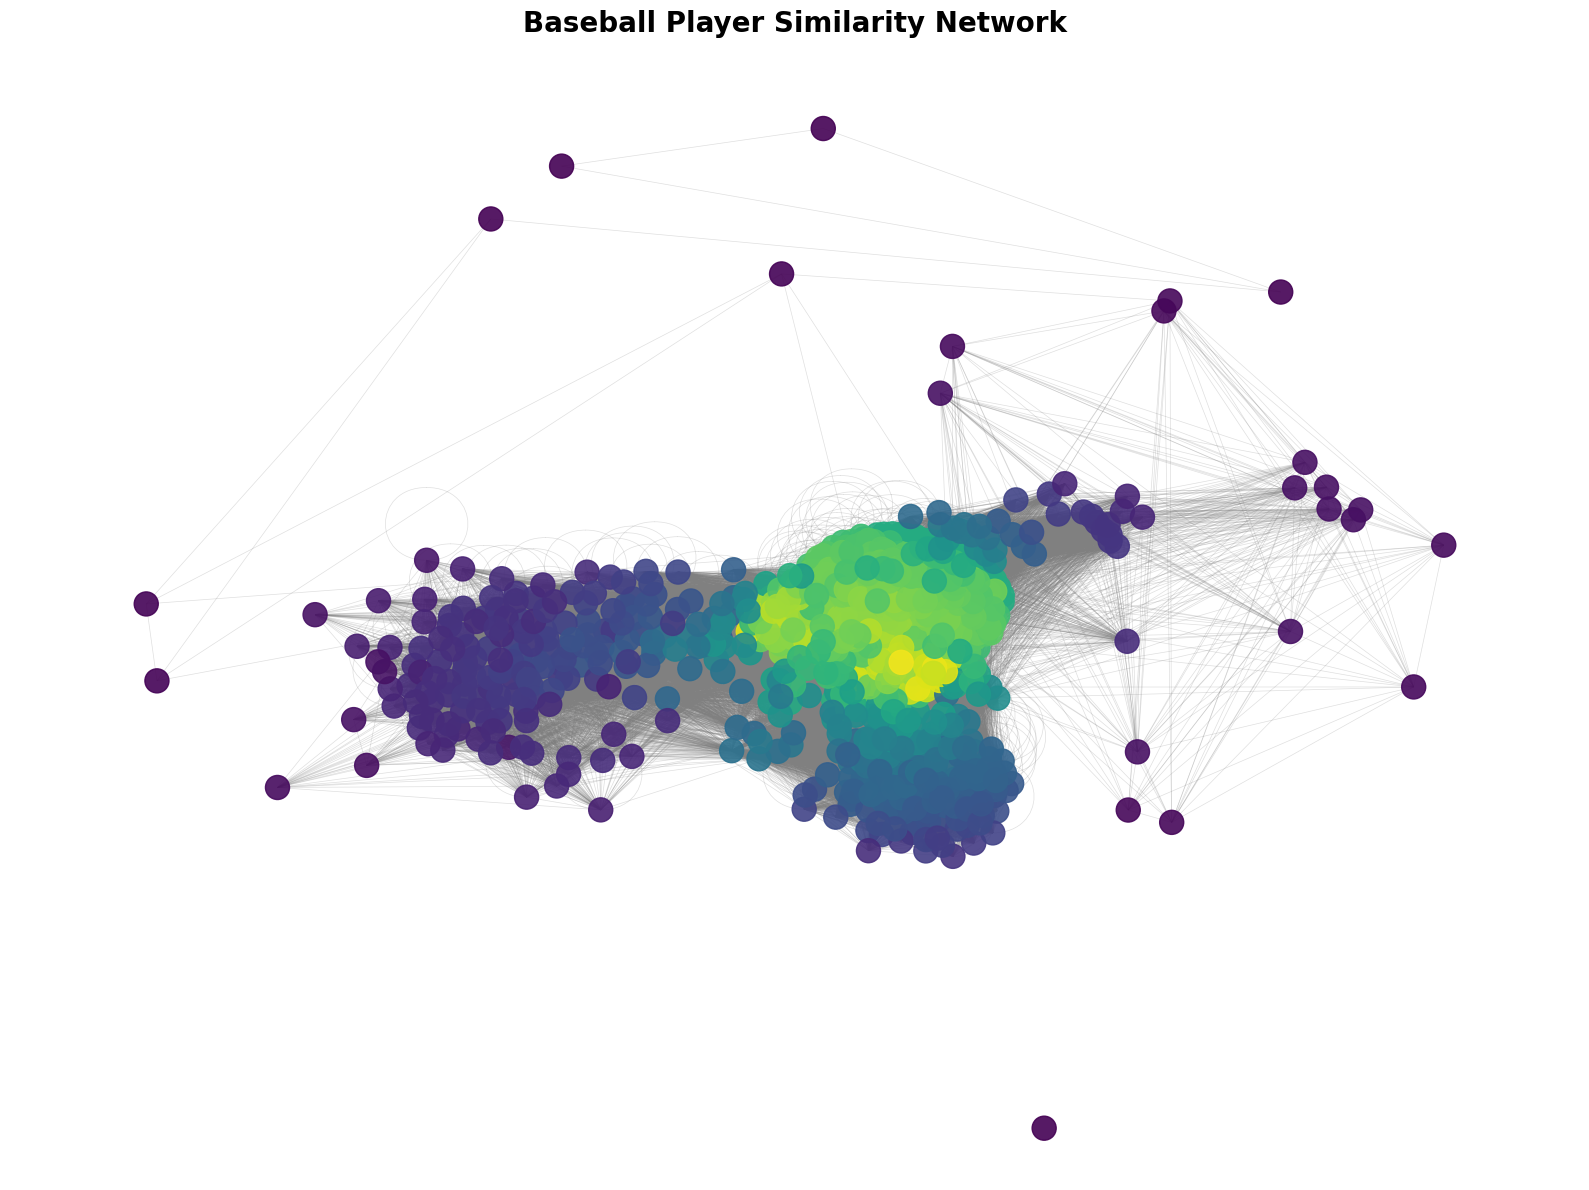

In [31]:
import matplotlib.pyplot as plt
import networkx as nx

# Create the figure FIRST
plt.figure(figsize=(16, 12))

# Calculate node connections
degrees = dict(g.degree())

# Create layout
pos = nx.spring_layout(
    g,
    seed=42,
    k=0.8,
    iterations=100
)


# Draw edges
nx.draw_networkx_edges(
    g,
    pos,
    width=0.5,
    alpha=0.25,
    edge_color="gray"
)

# Draw nodes
nx.draw_networkx_nodes(
    g,
    pos,
    node_color=list(degrees.values()),
    cmap="viridis",
    alpha=0.9
)

plt.title(
    "Baseball Player Similarity Network",
    fontsize=20,
    fontweight="bold"
)



plt.axis("off")
plt.tight_layout()
plt.show()



In [46]:
top_k = 20
c_degree = nx.degree_centrality(g)
for n in sorted(c_degree, key=c_degree.get, reverse=True)[:top_k]:
    print(n,c_degree[n], g.degree(n))

Steven Matz 0.8107109879963065 878
Sean Hjelle 0.8079409048938134 875
Abner Uribe 0.7987072945521698 865
Jordan Romano 0.7940904893813481 860
Michael Tonkin 0.7922437673130194 858
Bryan Baker 0.7857802400738688 851
Jesse Chavez 0.7848568790397045 850
Hunter Strickland 0.7830101569713758 848
Chris Stratton 0.7830101569713758 848
Justin Martinez 0.7793167128347184 844
Luis Garcia 0.7793167128347184 844
Aaron Ashby 0.778393351800554 843
Alexis Diaz 0.778393351800554 843
Sean Newcomb 0.7765466297322253 841
Roansy Contreras 0.7765466297322253 841
Daniel Lynch IV 0.7756232686980609 840
Brenan Hanifee 0.7728531855955678 837
Logan Allen 0.7728531855955678 837
Trevor Richards 0.7719298245614035 836
Isaac Mattson 0.7700831024930748 834


In [47]:
top_k = 20
e_degree = nx.eigenvector_centrality(g)
for n in sorted(c_degree, key=c_degree.get, reverse=True)[:top_k]:
    print(n,c_degree[n], g.degree(n))

Steven Matz 0.8107109879963065 878
Sean Hjelle 0.8079409048938134 875
Abner Uribe 0.7987072945521698 865
Jordan Romano 0.7940904893813481 860
Michael Tonkin 0.7922437673130194 858
Bryan Baker 0.7857802400738688 851
Jesse Chavez 0.7848568790397045 850
Hunter Strickland 0.7830101569713758 848
Chris Stratton 0.7830101569713758 848
Justin Martinez 0.7793167128347184 844
Luis Garcia 0.7793167128347184 844
Aaron Ashby 0.778393351800554 843
Alexis Diaz 0.778393351800554 843
Sean Newcomb 0.7765466297322253 841
Roansy Contreras 0.7765466297322253 841
Daniel Lynch IV 0.7756232686980609 840
Brenan Hanifee 0.7728531855955678 837
Logan Allen 0.7728531855955678 837
Trevor Richards 0.7719298245614035 836
Isaac Mattson 0.7700831024930748 834


In [48]:
stats = []
top_players = sorted(e_degree,
    key=e_degree.get,
    reverse=True)[:top_k]
for i in top_players:
    stats.append({
        "Player": i,
        "Eigenvector Centrality": e_degree[i],
        "Degree Centrality":c_degree[i],
        "Degree":g.degree(i)
    })
stats_df=pd.DataFrame(stats)
stats_df

,Player,Eigenvector Centrality,Degree Centrality,Degree
0,Sean Hjelle,0.043147,0.807941,875
1,Jordan Romano,0.043004,0.794090,860
2,Abner Uribe,0.042996,0.798707,865
3,Steven Matz,0.042917,0.810711,878
4,Jesse Chavez,0.042648,0.784857,850
5,Bryan Baker,0.042610,0.785780,851
6,Michael Tonkin,0.042595,0.792244,858
7,Sean Newcomb,0.042533,0.776547,841
8,Alexis Diaz,0.042423,0.778393,843
9,Hunter Strickland,0.042422,0.783010,848
